# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [45]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

/home/sandbox/personal-repos/Challenge_MultiplePassDetection/PandasAccesor/NOP.py:16: UserWarning: registration of accessor <class 'NOP.NOPAccessor'> under name 'nop' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  class NOPAccessor:


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from shapely.ops import polygonize, unary_union

from NOP import *


# Configuration

In [47]:
tol_deg  = 5
street_length = 10
sampling_distance = 10
dx = 1            # Thickness of each vertical bar
angles = np.arange(0, 190, 10)

# Query the surveys

In [48]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey['geometry'] = survey['Breadcrumb_wkt']
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'geometry', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)
survey_gdf.set_geometry('geometry', inplace=True)


# Algorithm starts here
## Prepare the surveys

In [49]:
survey_gdf.nop.prepare_survey_gdf()

Center of the bounds: POINT (565470.42276 5834822.6777)


In [50]:
cell_gdf = survey_gdf.nop.generate_grid()

803 splitters -> 864 cells


In [51]:
survey_gdf.nop.cell_gdf

,cell_idx,geometry
0,0,"POLYGON ((-616.557 -381.990, -616.496 -381.988..."
1,1,"POLYGON ((-614.870 -370.331, -614.715 -369.943..."
2,2,"POLYGON ((-608.243 -362.101, -608.117 -361.954..."
3,3,"POLYGON ((-608.117 -361.954, -607.855 -361.649..."
4,4,"POLYGON ((-601.466 -355.238, -592.868 -350.029..."
...,...,...
859,859,"POLYGON ((106.382 -234.514, 106.144 -234.101, ..."
860,860,"POLYGON ((426.429 -62.576, 426.542 -62.712, 42..."
861,861,"POLYGON ((-108.469 -33.615, -108.036 -33.978, ..."
862,862,"POLYGON ((180.912 -133.462, 179.380 -132.578, ..."


## Count the intersections by cell

In [52]:
cell_summary = survey_gdf.nop.count_nop()

/home/sandbox/personal-repos/Challenge_MultiplePassDetection/PandasAccesor/NOP.py:187: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  coords = list(poly.exterior.coords)
/home/sandbox/personal-repos/Challenge_MultiplePassDetection/PandasAccesor/NOP.py:201: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  


In [53]:
cell_summary

,cell_idx,geometry,intersections,boundaries,passes
0,0,"POLYGON ((564853.866 5834440.688, 564853.926 5...",20.0,3.0,6.666667
1,1,"POLYGON ((564855.553 5834452.346, 564855.708 5...",14.0,2.0,7.000000
2,2,"POLYGON ((564862.180 5834460.577, 564862.306 5...",NaN,NaN,NaN
3,3,"POLYGON ((564862.306 5834460.723, 564862.568 5...",14.0,2.0,7.000000
4,4,"POLYGON ((564868.956 5834467.440, 564877.555 5...",14.0,2.0,7.000000
...,...,...,...,...,...
859,859,"POLYGON ((565576.805 5834588.164, 565576.567 5...",NaN,NaN,NaN
860,860,"POLYGON ((565896.851 5834760.102, 565896.965 5...",NaN,NaN,NaN
861,861,"POLYGON ((565361.954 5834789.062, 565362.387 5...",NaN,NaN,NaN
862,862,"POLYGON ((565651.335 5834689.215, 565649.803 5...",4.0,3.0,1.333333


/tmp/ipykernel_66231/575504383.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axa.legend()


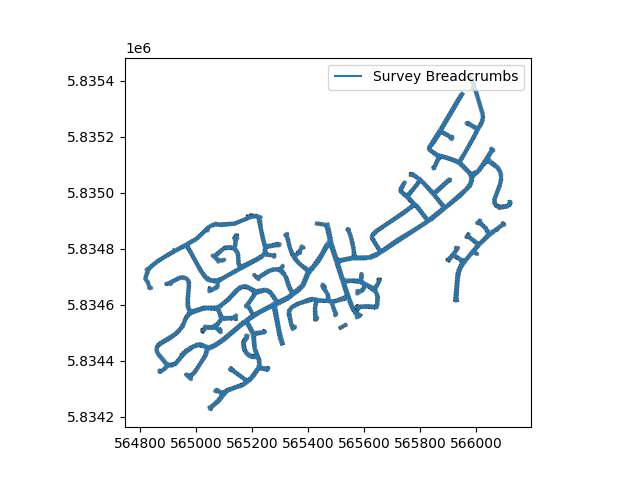

In [54]:
fig,axa = plt.subplots()
cell_gdf.plot(edgecolor='black', facecolor='none', alpha=0.5, ax=axa, label='Grid Cells')
survey_gdf.plot(ax=axa, label='Survey Breadcrumbs')
axa.legend()

/tmp/ipykernel_66231/1960337944.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


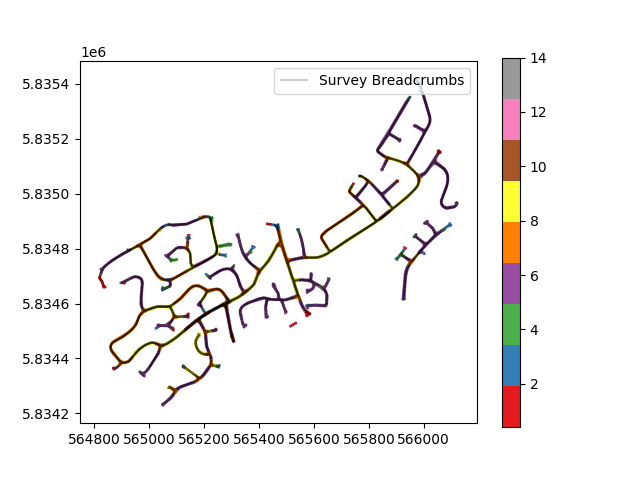

In [55]:
fig, ax = plt.subplots()
plot = cell_summary.plot(column='passes', cmap='Set1', ax=ax, legend=True, label='Number of passes')
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs', color='black', alpha=0.2)
# Set title for colorbar
if plot.get_legend() is not None and hasattr(plot.get_legend(), 'set_title'):
    plot.get_legend().set_title('number of passes')
ax.legend()

In [56]:
cell_summary

,cell_idx,geometry,intersections,boundaries,passes
0,0,"POLYGON ((564853.866 5834440.688, 564853.926 5...",20.0,3.0,6.666667
1,1,"POLYGON ((564855.553 5834452.346, 564855.708 5...",14.0,2.0,7.000000
2,2,"POLYGON ((564862.180 5834460.577, 564862.306 5...",NaN,NaN,NaN
3,3,"POLYGON ((564862.306 5834460.723, 564862.568 5...",14.0,2.0,7.000000
4,4,"POLYGON ((564868.956 5834467.440, 564877.555 5...",14.0,2.0,7.000000
...,...,...,...,...,...
859,859,"POLYGON ((565576.805 5834588.164, 565576.567 5...",NaN,NaN,NaN
860,860,"POLYGON ((565896.851 5834760.102, 565896.965 5...",NaN,NaN,NaN
861,861,"POLYGON ((565361.954 5834789.062, 565362.387 5...",NaN,NaN,NaN
862,862,"POLYGON ((565651.335 5834689.215, 565649.803 5...",4.0,3.0,1.333333
